### Install libraries

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn hmmlearn yfinance plotly streamlit

### Create Main Dataset

In [3]:
import yfinance as yf
import pandas as pd

def load_data():

    df = yf.download(
        "ORCL",
        start="2023-05-08",
        end="2026-05-08"
    )

    df.columns = df.columns.get_level_values(0)

    df.reset_index(inplace=True)

    return df
OracleData = load_data()
OracleData

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2023-05-08,93.429710,93.902697,93.091863,93.709643,5314800
1,2023-05-09,92.802277,93.526239,92.763664,92.860191,6333500
2,2023-05-10,94.134361,94.288810,92.918110,93.429709,5935300
3,2023-05-11,94.057159,94.240558,92.995342,94.153686,5144500
4,2023-05-12,94.452911,94.520481,93.564853,94.221246,4994700
...,...,...,...,...,...,...
748,2026-05-01,171.830002,174.300003,166.149994,166.419998,26318000
749,2026-05-04,180.289993,183.500000,174.259995,176.020004,33504500
750,2026-05-05,185.350006,186.520004,179.000000,182.130005,23497200
751,2026-05-06,194.029999,194.289993,182.669998,186.199997,27685500


### Create Market features

In [22]:
import pandas as pd
import numpy as np

def create_features(df):

    # Daily returns
    df['Returns'] = df['Close'].pct_change()

    # Rolling volatility
    df['Volatility_20'] = (
        df['Returns']
        .rolling(20)
        .std()
    )

    # Momentum
    df['Momentum_20'] = (
        df['Close']
        .pct_change(20)
    )

    # Moving average ratio
    ma20 = df['Close'].rolling(20).mean()
    ma100 = df['Close'].rolling(100).mean()

    df['MA_Ratio'] = ma20 / ma100

    # Drawdown
    df['Rolling_Max'] = df['Close'].cummax()

    df['Drawdown'] = (
        df['Close'] / df['Rolling_Max']
    ) - 1

    df.dropna(inplace=True)

    return df

### Create regime using kmeans

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def detect_regimes(df):

    features = df[
        [
            'Returns',
            'Volatility_20',
            'Momentum_20',
            'Drawdown'
        ]
    ]

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(features)

    model = KMeans(
        n_clusters=3,
        random_state=42
    )

    df['Regime'] = model.fit_predict(X_scaled)
    # print(f"these are regime values:\n{df['Regime']}")
   
    

    return df

### Analysis for Regime detection

In [27]:
def regime_statistics(df):

    Analysis1 = df.groupby('Regime')[
        ['Returns', 'Volatility_20']
    ].agg(
        ['mean', 'std', 'min', 'max']
    )
    print(Analysis1) 
    
    Analysis2 = df.groupby('Regime')[
        [
            'Returns',
            'Volatility_20',
            'Momentum_20',
            'Drawdown'
        ]
    ].mean()
    print(Analysis2)

### Visualization

In [14]:
import matplotlib.pyplot as plt

def plot_regimes(df):
    regime_labels = {
    0: 'Stable Bull',
    1: 'Bear Crisis',
    2: 'Recovery Rally'
    }
    
    df['Regime_Name'] = (
        df['Regime']
        .map(regime_labels)
    )

    colors = {
        'Stable Bull': 'green',
        'Bear Crisis': 'red',
        'Recovery Rally': 'orange'
    }

    plt.figure(figsize=(15,7))

    for regime_name, color in colors.items():

        subset = df[
            df['Regime_Name'] == regime_name
        ]

        plt.scatter(
            subset['Date'],
            subset['Close'],
            color=color,
            label=regime_name,
            s=12
        )

    plt.plot(
        df['Date'],
        df['Close'],
        color='gray',
        alpha=0.3
    )

    plt.title('Oracle Market Regimes')

    plt.xlabel('Date')
    plt.ylabel('Price')

    plt.legend()

    plt.grid(alpha=0.2)

    plt.show()

### Run regime Analysis

In [28]:
def main():

    df = load_data()

    df = create_features(df)

    df = detect_regimes(df)

    regime_statistics(df)
   
if __name__ == "__main__":
    main()

[*********************100%***********************]  1 of 1 completed

Price    Returns                               Volatility_20            \
            mean       std       min       max          mean       std   
Regime                                                                   
0       0.014051  0.045162 -0.062346  0.359488      0.043235  0.020493   
1      -0.004784  0.035204 -0.137908  0.126946      0.033506  0.005016   
2       0.000586  0.017614 -0.066737  0.071664      0.017610  0.005530   

Price                       
             min       max  
Regime                      
0       0.019454  0.089702  
1       0.024218  0.043016  
2       0.009246  0.038340  
Price    Returns  Volatility_20  Momentum_20  Drawdown
Regime                                                
0       0.014051       0.043235     0.211221 -0.084705
1      -0.004784       0.033506    -0.097679 -0.356858
2       0.000586       0.017610     0.024713 -0.078959


### Run visualization plot

[*********************100%***********************]  1 of 1 completed


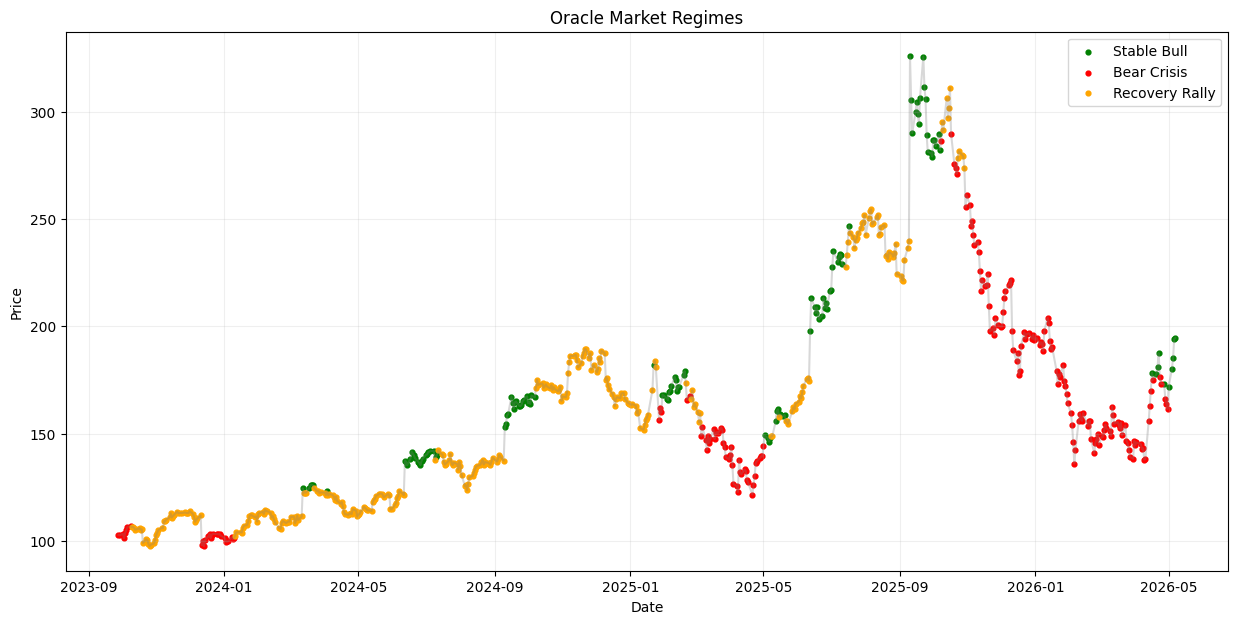

In [30]:
def main():

    df = load_data()

    df = create_features(df)

    df = detect_regimes(df)

    plot_regimes(df)
    
   
if __name__ == "__main__":
    main()